# House price prediction

## Load dataset

In [ ]:
!gdown 1Dh_y7gFDUa2sD72_cKIa209dhbMVoGEd

Downloading...
From: https://drive.google.com/uc?id=1Dh_y7gFDUa2sD72_cKIa209dhbMVoGEd
To: /content/train-house-prices-advanced-regression-techniques.csv
100% 461k/461k [00:00<00:00, 97.2MB/s]


In [ ]:
# Google Colab Setup - Mount Google Drive
from google.colab import drive
import os
import pathlib

# Mount Google Drive
drive.mount('/content/drive')

# Define base path for all project files
BASE_PATH = "/content/drive/MyDrive/Colab_Notebooks/Project-5.1/"
print(f"📁 Base path set to: {BASE_PATH}")

# Create base directory if it doesn't exist
pathlib.Path(BASE_PATH).mkdir(parents=True, exist_ok=True)

# Define subdirectories for different components
MLFLOW_DIR = BASE_PATH + "mlruns"
CACHE_DIR = BASE_PATH + "training_cache"
LOGS_DIR = BASE_PATH + "logs"

# Create all necessary directories
for directory in [MLFLOW_DIR, CACHE_DIR, LOGS_DIR]:
    pathlib.Path(directory).mkdir(parents=True, exist_ok=True)
    print(f"📂 Created directory: {directory}")

print("✅ Google Drive connection and directory structure established!")

Mounted at /content/drive
📁 Base path set to: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/
📂 Created directory: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/mlruns
📂 Created directory: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/training_cache
📂 Created directory: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/logs
✅ Google Drive connection and directory structure established!


In [ ]:
# Install required packages with multithreading support, MLflow, and ngrok
!pip install optuna xgboost catboost lightgbm joblib tqdm mlflow pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [ ]:
# Import libraries with multithreading support
import warnings
warnings.filterwarnings("ignore")

import math
import json
import itertools
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import threading

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import ElasticNet, Ridge, Lasso, RidgeCV
from sklearn.svm import SVR
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer

# MLflow imports
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.catboost
import mlflow.lightgbm

# Optional dependencies
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import optuna
    HAS_OPTUNA = True
except Exception:
    HAS_OPTUNA = False

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except Exception:
    HAS_CAT = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

# Set random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")
print(f"XGBoost available: {HAS_XGB}")
print(f"Optuna available: {HAS_OPTUNA}")
print(f"CatBoost available: {HAS_CAT}")
print(f"LightGBM available: {HAS_LGBM}")
print("Multithreading support: Available")
print("MLflow tracking: Available")

Libraries imported successfully!
XGBoost available: True
Optuna available: True
CatBoost available: True
LightGBM available: True
Multithreading support: Available
MLflow tracking: Available


In [ ]:
import os
#Vì Google Colab chạy trên một máy ảo không có địa chỉ IP công khai,
#nên chúng ta cần ngrok để làm cầu nối
from pyngrok import ngrok
from google.colab import userdata

# 1. Cấu hình đường dẫn lưu trữ
MLFLOW_DIR = "/content/mlflow_data"
if not os.path.exists(MLFLOW_DIR):
    os.makedirs(MLFLOW_DIR)

# 2. Thiết lập ngrok (Lấy token từ Colab Secrets)
NGROK_TOKEN = userdata.get("NGROK_AUTH_TOKEN")
ngrok.set_auth_token(NGROK_TOKEN)

# Dọn dẹp các tunnel cũ nếu có
ngrok.kill()

# Mở tunnel mới tới cổng 5000
public_url = ngrok.connect(5000).public_url
print(f"🌐 MLflow UI Public URL: {public_url}")

# 3. Khởi chạy MLflow UI (Chạy ngầm)
# --allowed-hosts: cho phép truy cập qua domain của ngrok
get_ipython().system_raw(
    f"mlflow ui --backend-store-uri file:{MLFLOW_DIR} --host 0.0.0.0 --port 5000 "
    f"--allowed-hosts {public_url.split('//')[1]} &"
)

# 4. Cấu hình Tracking trong Python
mlflow.set_tracking_uri(f"file:{MLFLOW_DIR}")
mlflow.set_experiment("House_Price_Prediction")

print("✅ MLflow đã sẵn sàng! Bạn có thể bắt đầu log model.")

2026/03/30 01:27:47 INFO mlflow.tracking.fluent: Experiment with name 'House_Price_Prediction' does not exist. Creating a new experiment.


🌐 MLflow UI Public URL: https://calcific-thermostatically-alecia.ngrok-free.dev
✅ MLflow đã sẵn sàng! Bạn có thể bắt đầu log model.


In [ ]:
import os

# Danh sách các thư viện cần thiết cho VS Code
reqs = [
    "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn",
    "xgboost", "catboost", "lightgbm", "optuna", "mlflow",
    "pyngrok", "pyyaml", "joblib", "tqdm"
]

with open('requirements.txt', 'w') as f:
    for r in reqs:
        f.write(f"{r}\n")

print("✅ Đã tạo file requirements.txt!")
print("👉 Bạn hãy tải file này và file Notebook (.ipynb) về máy để chạy trên VS Code.")

✅ Đã tạo file requirements.txt!
👉 Bạn hãy tải file này và file Notebook (.ipynb) về máy để chạy trên VS Code.


In [ ]:
class MLflowTrainingCacheManager:
    """Enhanced caching system for training and evaluation results with MLflow integration"""

    def __init__(self, base_path="training_cache"):
        self.base_path = Path(base_path)
        self.cache_lock = threading.Lock()

    def _ensure_cache_dir(self):
        """Create cache directory only when needed"""
        try:
            self.base_path.mkdir(parents=True, exist_ok=True)
        except Exception as e:
            print(f"⚠️ Could not create cache directory: {e}")

    def save_results(self, results, filename, metadata=None):
        """Save training/evaluation results to cache with MLflow logging"""
        with self.cache_lock:
            try:
                self._ensure_cache_dir()

                cache_file = self.base_path / f"{filename}.pkl"
                meta_file = self.base_path / f"{filename}_meta.json"

                # Save results
                with open(cache_file, 'wb') as f:
                    pickle.dump(results, f)

                # Save metadata
                if metadata is None:
                    metadata = {}
                metadata.update({
                    'timestamp': datetime.now().isoformat(),
                    'filename': filename
                })

                with open(meta_file, 'w') as f:
                    json.dump(metadata, f, indent=2)

                # Log to MLflow
                with mlflow.start_run(run_name=f"Cache_Save_{filename}", nested=True):
                    mlflow.log_param("cache_filename", filename)
                    mlflow.log_param("cache_timestamp", metadata['timestamp'])
                    mlflow.log_artifact(str(cache_file), "cache")
                    mlflow.log_artifact(str(meta_file), "cache_metadata")

                print(f"💾 Cached training results: {filename}")
                return True
            except Exception as e:
                print(f"❌ Cache save failed: {e}")
                return False

    def load_results(self, filename):
        """Load training/evaluation results from cache"""
        with self.cache_lock:
            try:
                cache_file = self.base_path / f"{filename}.pkl"
                meta_file = self.base_path / f"{filename}_meta.json"

                if not cache_file.exists():
                    return None, None

                # Load results from file pickle :3
                with open(cache_file, 'rb') as f:
                    results = pickle.load(f)

                # Load metadata
                metadata = None
                if meta_file.exists():
                    with open(meta_file, 'r') as f:
                        metadata = json.load(f)

                # Log cache hit to MLflow
                with mlflow.start_run(run_name=f"Cache_Load_{filename}", nested=True):
                    mlflow.log_param("cache_filename", filename)
                    mlflow.log_param("cache_hit", True)
                    if metadata:
                        mlflow.log_param("cache_timestamp", metadata.get('timestamp', 'unknown'))

                print(f"📂 Loaded cached results: {filename}")
                return results, metadata
            except Exception as e:
                print(f"❌ Cache load failed: {e}")
                return None, None

    def results_exist(self, filename):
        """Check if cached results exist"""
        cache_file = self.base_path / f"{filename}.pkl"
        return cache_file.exists()

# Initialize enhanced cache manager with BASE_PATH
training_cache = MLflowTrainingCacheManager(CACHE_DIR)
print("✅ Enhanced training cache system with MLflow integration initialized!")
print(f"📁 Cache directory: {CACHE_DIR}")
print(f"🔗 All cache files will be saved to: {CACHE_DIR}")

✅ Enhanced training cache system with MLflow integration initialized!
📁 Cache directory: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/training_cache
🔗 All cache files will be saved to: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/training_cache


In [ ]:
#importing Dataset
house_df = pd.read_csv("/content/train-house-prices-advanced-regression-techniques.csv")

#checking dataset
house_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Ghi nhật ký quá trình load dữ liệu vào MLflow
with mlflow.start_run(run_name="Data_Loading_Info", nested=True):
    # Tính toán các thông số cơ bản
    rows, cols = house_df.shape
    total_missing = house_df.isnull().sum().sum()

    # Log tham số (Params)
    mlflow.log_params({
        "dataset_shape": f"{rows}x{cols}",
        "total_columns": cols,
        "total_rows": rows
    })

    # Log chỉ số (Metrics)
    mlflow.log_metric("missing_values_total", total_missing)
    mlflow.log_metric("missing_percentage", (total_missing / (rows * cols)) * 100)

    print(f"✅ Đã log thông tin house_df ({rows} dòng, {cols} cột) lên MLflow.")

✅ Đã log thông tin house_df (1460 dòng, 81 cột) lên MLflow.


In [ ]:
# Remove ID column as it doesn't contribute to model learning
house_df = house_df.drop('Id', axis=1)

house_df.shape
print("Full train dataset shape is {}".format(house_df.shape))

Full train dataset shape is (1460, 80)


## EDA

In [ ]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

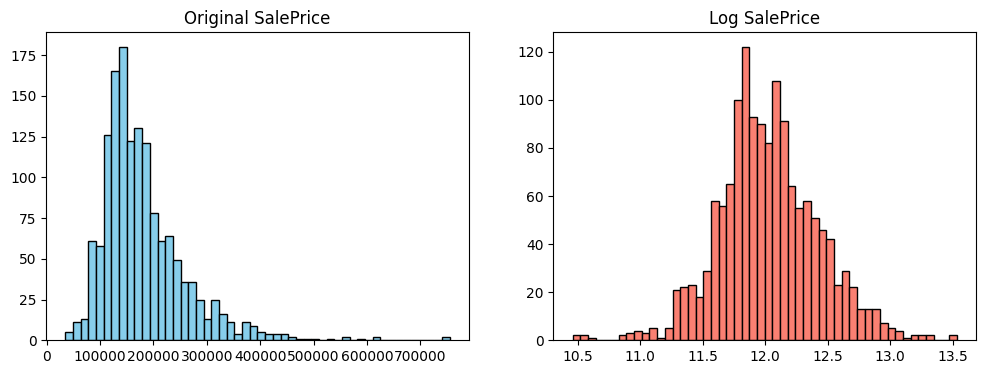

✅ Đã log EDA cho 1460 dòng dữ liệu.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import mlflow

with mlflow.start_run(run_name="Data_Exploration", nested=True):
    # 1. Log các chỉ số thống kê của biến mục tiêu (SalePrice)
    stats = house_df['SalePrice'].describe().to_dict()
    # MLflow không nhận ký tự '%' nên ta đổi tên key (ví dụ: 50% -> median)
    clean_stats = {k.replace('50%', 'median').replace('%', 'pct'): v for k, v in stats.items()}
    mlflow.log_metrics(clean_stats)

    # 2. Log thông tin dữ liệu thiếu và kiểu dữ liệu
    mlflow.log_metric("cols_with_missing", house_df.isnull().any().sum())
    for dtype, count in house_df.dtypes.value_counts().items():
        mlflow.log_metric(f"dtype_{str(dtype)}", count)

    # 3. Vẽ đồ thị phân phối (Gộp 2 đồ thị vào 1 dòng)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(house_df['SalePrice'], bins=50, color='skyblue', edgecolor='black')
    axes[0].set_title('Original SalePrice')

    axes[1].hist(np.log1p(house_df['SalePrice']), bins=50, color='salmon', edgecolor='black')
    axes[1].set_title('Log SalePrice')

    # Lưu và đẩy ảnh lên MLflow
    plot_path = "target_distribution.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)
    plt.show()

    print(f"✅ Đã log EDA cho {house_df.shape[0]} dòng dữ liệu.")

## Numerical data distribution

In [ ]:
list(set(house_df.dtypes.tolist()))

[dtype('int64'), dtype('O'), dtype('float64')]

In [ ]:
df_num = house_df.select_dtypes(include = ['float64', 'int64'])
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


'\nDễ thấy có biến LotFrontage, LotArea, GrLivArea, TotalBsmtSF, BsmtFinSF1,\nBsmtFinSF2, BsmtUnfSF,... thậm chí SalePrice cũng lệch phải.\n'

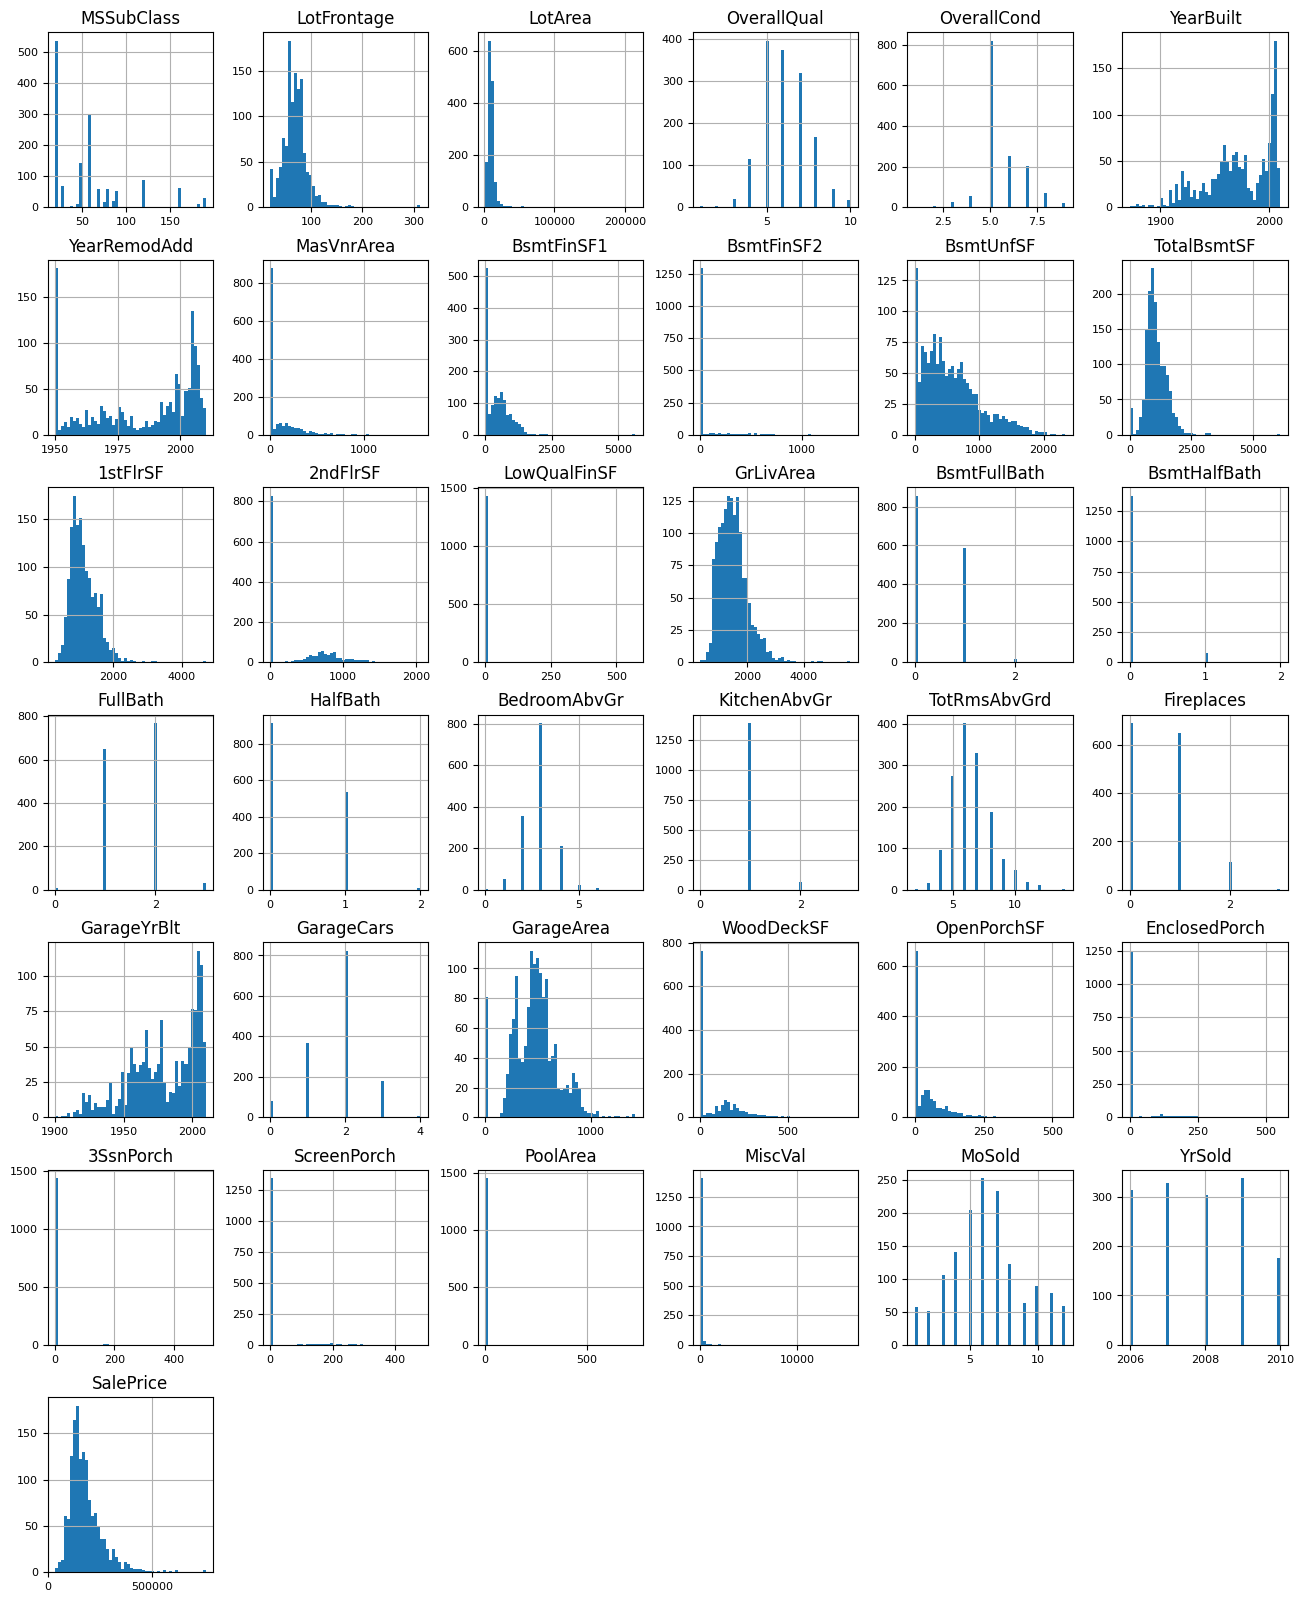

In [ ]:
#Plot distribution for all numerical feature
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

"""
Dễ thấy có biến LotFrontage, LotArea, GrLivArea, TotalBsmtSF, BsmtFinSF1,
BsmtFinSF2, BsmtUnfSF,... thậm chí SalePrice cũng lệch phải.
"""

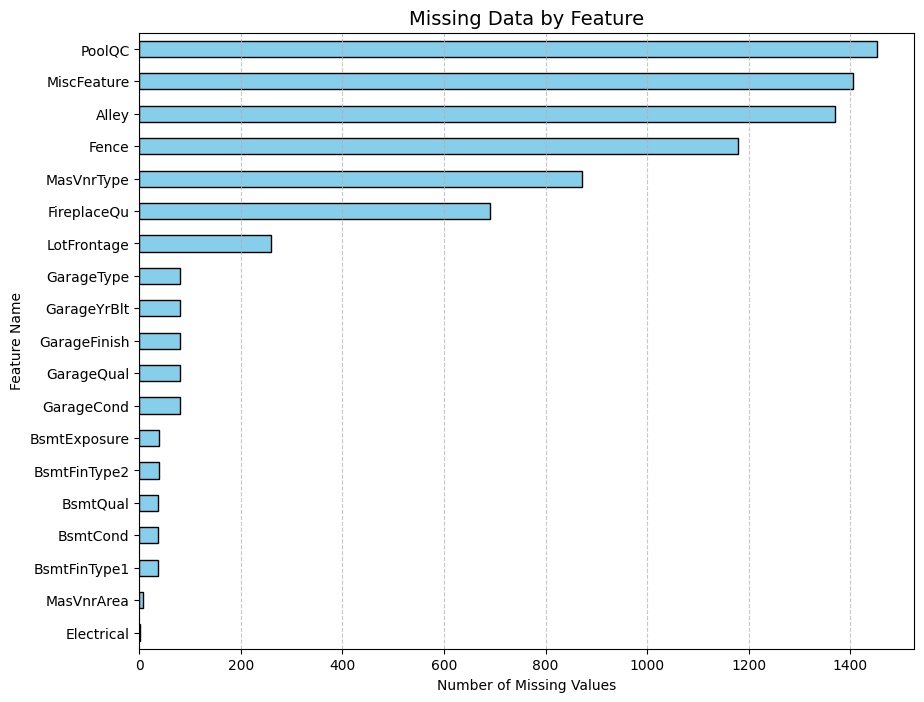

In [ ]:
# Checking missing values (horizontal view)
missing = house_df.isnull().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
missing.plot.barh(color='skyblue', edgecolor='black')
plt.title("Missing Data by Feature", fontsize=14)
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.show()

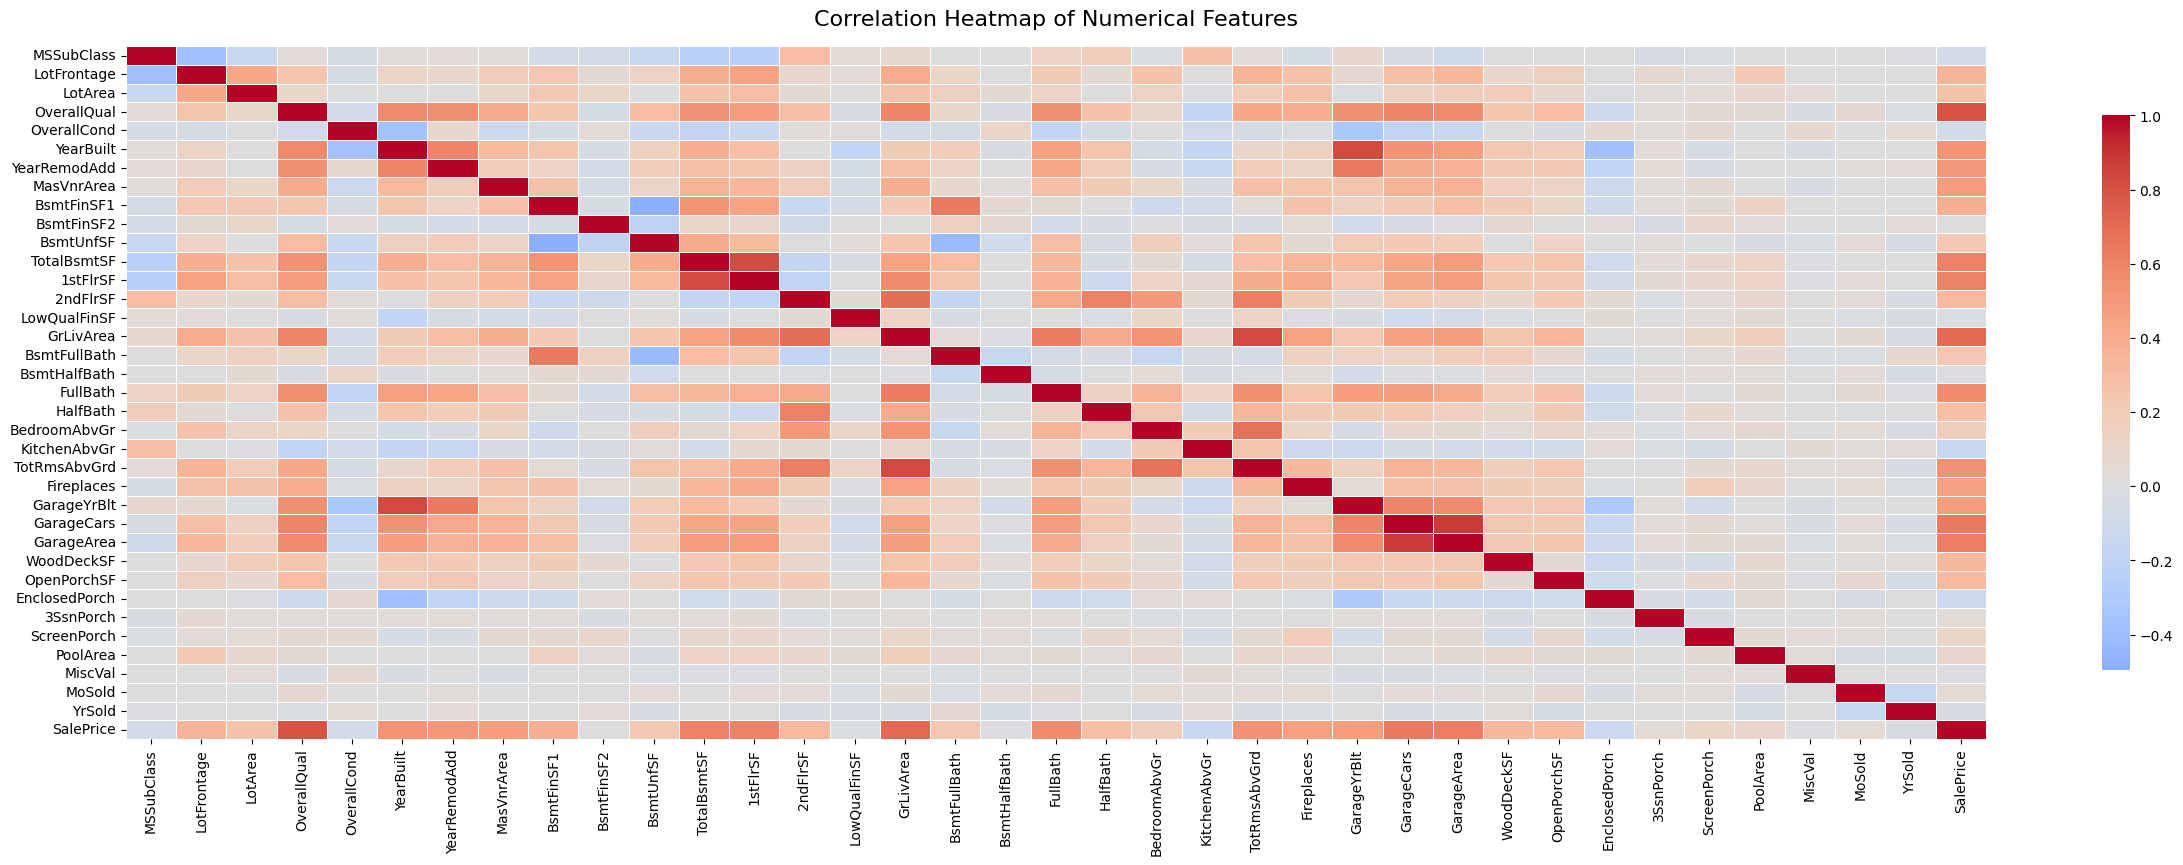

In [ ]:
plt.figure(figsize=(30, 9))
sns.heatmap(
    house_df.corr(numeric_only=True),
    cmap="coolwarm",
    linewidths=0.5,
    center=0,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16, pad=15)
plt.show()


## Preprocessing data


Ở đây data có 5 loại:

1.   Biến phân loại (Categorical)
2.   Biến liên tục (Continuos)
3.   Biến thứ tự (Ordinal)
4.   Biến liên tục nma bị thiếu (Numerical Absence)
5.   Phần còn lại (remainder)



In [ ]:
# Add mapping for concrete data
ORDINAL_MAP_CANONICAL = {
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],
    "GarageQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "PoolQC": ["NA", "Fa", "TA", "Gd", "Ex"],
    "Fence": ["NA", "MnWw", "GdWo", "MnPrv", "GdPrv"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "PavedDrive": ["N", "P", "Y"],
    "Street": ["Grvl", "Pave"],
    "Alley": ["NA", "Grvl", "Pave"],
    "CentralAir": ["N", "Y"]
}

# Log ordinal mapping to MLflow
with mlflow.start_run(run_name="Transformers_Setup", nested=True):
    mlflow.log_param("ordinal_features_count", len(ORDINAL_MAP_CANONICAL))
    mlflow.log_param("ordinal_features", list(ORDINAL_MAP_CANONICAL.keys()))

    # Log mapping details
    for feature, mapping in ORDINAL_MAP_CANONICAL.items():
        mlflow.log_param(f"ordinal_{feature}_levels", len(mapping))
        mlflow.log_param(f"ordinal_{feature}_mapping", mapping)

print("Ordinal mapping defined for", len(ORDINAL_MAP_CANONICAL), "features")

Ordinal mapping defined for 20 features


In [ ]:
# Chuyển chữ thành số nhưng vẫn giữ được mối quan hệ thứ bậc giữa các giá trị.
class OrdinalMapper(BaseEstimator, TransformerMixin):
    """Maps ordinal categorical variables to numeric values based on predefined order"""
    def __init__(self, mapping):
        self.mapping = mapping
        self.maps_ = {}

    # Triển khai lại phương thức fit để học quy luật từ dữ liệu cũ
    def fit(self, X, y=None):
        self.maps_ = {}
        for col, order in self.mapping.items():
            if col in X.columns:
                self.maps_[col] = {v: i for i, v in enumerate(order)}  # Param học từ data
        return self

    # Triển khai lại phương thức transform(X) để áp dụng quy luật đó vào dữ liệu mới
    def transform(self, X):
        X = X.copy()
        for col, m in self.maps_.items():
            X[col] = X[col].map(m)
        return X

In [ ]:
# Tạo thêm một cột mới có hậu tố _was_missing (Trống - 1; Có data - 0)
class MissingnessIndicator(BaseEstimator, TransformerMixin):
    """Creates binary indicators for missing values in numeric columns"""
    def __init__(self, cols=None, auto_numeric=True):
        self.cols = cols
        self.auto_numeric = auto_numeric
        self.cols_ = []

    def fit(self, X, y=None):
        if self.cols is not None:
            self.cols_ = [c for c in self.cols if c in X.columns]
        elif self.auto_numeric:
            num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
            # Nếu một cột số không có giá trị thiếu nào trong tập Train, nó sẽ không tạo thêm cột với hậu tố _was_missing vô ích.
            self.cols_ = [c for c in num_cols if X[c].isna().any()]
        else:
            self.cols_ = []
        return self

    def transform(self, X):
        X = X.copy()
        for c in self.cols_:
            X[f"{c}_was_missing"] = X[c].isna().astype(int)
        return X

In [ ]:
"""
Kiểm tra tần suất xuất hiện của các giá trị.
Nếu một giá trị xuất hiện ít hơn min_count (mặc định là 20 lần),
nó sẽ bị đổi tên thành "Other"

Mục đích: Tránh việc mô hình bị quá khớp (overfitting) vào các nhóm quá nhỏ,
đồng thời làm gọn số lượng biến sau khi One-Hot Encoding.
"""
class RarePooler(BaseEstimator, TransformerMixin):
    """
    Pools rare categories into 'Other'.
    Hỗ trợ cả min_count (số lượng) và min_perc (tỷ lệ %).
    """
    def __init__(self, cols, min_count=None, min_perc=None):
        self.cols = cols
        self.min_count = min_count
        self.min_perc = min_perc
        self.keep_levels_ = {}

    def fit(self, X, y=None):
        self.keep_levels_ = {}
        n_samples = len(X)

        # Xác định ngưỡng (threshold)
        # Nếu có min_perc thì ưu tiên dùng tỷ lệ để ổn định khi chia Fold
        threshold = self.min_count if self.min_count is not None else 0
        if self.min_perc is not None:
            threshold = max(threshold, self.min_perc * n_samples)

        for c in self.cols:
            if c in X.columns:
                # Đếm tần suất
                vc = X[c].value_counts(dropna=False)
                # Chỉ giữ những giá trị vượt ngưỡng
                self.keep_levels_[c] = set(vc[vc >= threshold].index.astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        for c, keep in self.keep_levels_.items():
            if c in X.columns:
                X[c] = X[c].astype(str)
                # Những gì không nằm trong danh sách 'keep' -> 'Other'
                X[c] = np.where(X[c].isin(keep), X[c], "Other")
        return X

# Ví dụ áp dụng vào RarePooler
class SmartRarePooler(RarePooler):
    def fit(self, X, y=None):
        super().fit(X, y)
        log_to_mlflow({
            "rare_pooler_cols": len(self.cols),
            "rare_pooler_min_threshold": self.min_count
        })
        return self

In [ ]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None, alpha=10):
        self.cols = cols
        self.alpha = alpha
        self.mapping_ = {}
        self.global_mean_ = None

    def fit(self, X, y):
        self.global_mean_ = y.mean()
        for col in self.cols:
            agg = y.groupby(X[col]).agg(['count', 'mean'])
            counts = agg['count']
            means = agg['mean']
            smooth = (counts * means + self.alpha * self.global_mean_) / (counts + self.alpha)
            self.mapping_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X_out = X.copy()
        for col, map_dict in self.mapping_.items():
            X_out[f"TE_{col}"] = X_out[col].map(map_dict).fillna(self.global_mean_)
        return X_out

class DataSanitizer(BaseEstimator, TransformerMixin):
    """
    Xử lý vô cực và NaN cho cả DataFrame và NumPy Array.
    """
    def fit(self, X, y=None):
        # Nếu là DataFrame, ghi lại danh sách cột không hoàn toàn trống
        if hasattr(X, 'select_dtypes'):
            self.keep_cols_idx_ = [i for i, col in enumerate(X.columns) if not X[col].isnull().all()]
            self.is_df_ = True
        else:
            # Nếu là NumPy array, kiểm tra các cột không toàn NaN
            self.keep_cols_idx_ = [i for i in range(X.shape[1]) if not np.all(np.isnan(X[:, i]))]
            self.is_df_ = False
        return self

    def transform(self, X):
        # Chuyển về numpy để xử lý inf đồng nhất
        if hasattr(X, 'values'):
            X_out = X.values.copy()
        else:
            X_out = X.copy()

        # Xử lý vô cực (Inf -> NaN)
        X_out = np.where(np.isinf(X_out), np.nan, X_out)

        # Chỉ giữ các cột hợp lệ
        X_out = X_out[:, self.keep_cols_idx_]

        return X_out

def log_to_mlflow(params_dict):
    if mlflow.active_run():
        mlflow.log_params(params_dict)

## 3. Domain-Specific Feature Engineering

In [ ]:
def add_domain_features(df):
    """Phiên bản tinh gọn: Tạo các đặc trưng bất động sản quan trọng"""
    df = df.copy()

    # 1. Tổng diện tích & Số phòng tắm (Dùng fillna(0) trực tiếp)
    df["TotalSF"] = df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]].fillna(0).sum(axis=1)
    df["TotalBath"] = (df["FullBath"].fillna(0) + 0.5*df["HalfBath"].fillna(0) +
                       df["BsmtFullBath"].fillna(0) + 0.5*df["BsmtHalfBath"].fillna(0))

    # 2. Tuổi thọ nhà (Tính toán theo Vector)
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

    # 3. Đặc trưng nhị phân & Tỷ lệ
    df["Has2ndFlr"] = (df["2ndFlrSF"] > 0).astype(int)
    df["TotalPorchSF"] = df[["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF"]].fillna(0).sum(axis=1)

    # 4. Tương tác quan trọng (Quality * Area)
    if "OverallQual" in df.columns:
        df["Quality_Area_Interaction"] = df["OverallQual"] * df["GrLivArea"]

    # 5. Xử lý tính chu kỳ (Tháng bán)
    if "MoSold" in df.columns:
        df["MoSold_sin"] = np.sin(2 * np.pi * df["MoSold"] / 12)
        df["MoSold_cos"] = np.cos(2 * np.pi * df["MoSold"] / 12)

    # 6. Gom nhóm đặc trưng (Interaction)
    if "Neighborhood" in df.columns and "BldgType" in df.columns:
        df["Loc_Type"] = df["Neighborhood"].astype(str) + "_" + df["BldgType"].astype(str)

    # 7. Giới hạn ngoại lai (Clipping)
    if "LotArea" in df.columns:
        df["LotArea_clip"] = df["LotArea"].clip(upper=df["LotArea"].quantile(0.99))

    return df

# Log nhanh vào MLflow
with mlflow.start_run(run_name="Feature_Engineering", nested=True):
    mlflow.log_param("feature_engineering_enabled", True)
    mlflow.log_param("domain_features", [
        "TotalSF", "TotalBath", "HouseAge", "RemodAge", "GarageAge",
        "IsRemodeled", "Has2ndFlr", "TotalPorchSF", "BathPerBedroom",
        "RoomsPerArea", "LotAreaRatio", "MoSold_sin", "MoSold_cos",
        "Neighborhood_BldgType", "Ln_TotalSF", "IQ_OQ_GrLiv", "IQ_OQ_TotalSF", "LotArea_clip"
    ])
    mlflow.log_param("num_features_created", 10)
    print("✅ Đã tạo và log các đặc trưng domain mới.")

✅ Đã tạo và log các đặc trưng domain mới.


In [ ]:
def build_feature_lists(df_train, df_test):
    """Build feature lists for different preprocessing pipelines"""
    for df in (df_train, df_test):
        if "MSSubClass" in df.columns:
            df["MSSubClass"] = df["MSSubClass"].astype(str)

    all_cols = df_train.drop(columns=["SalePrice"], errors="ignore").columns

    ord_cols = [c for c in ORDINAL_MAP_CANONICAL.keys() if c in all_cols]
    cat_cols = [c for c in all_cols if (df_train[c].dtype == "object") and (c not in ord_cols)]
    num_cols = [c for c in all_cols if pd.api.types.is_numeric_dtype(df_train[c]) and c not in ord_cols]

    num_abs_candidates = []
    for c in num_cols:
        if df_train[c].isna().any() or df_test[c].isna().any():
            num_abs_candidates.append(c)

    num_cont = [c for c in num_cols if c not in num_abs_candidates]
    return cat_cols, ord_cols, num_cont, num_abs_candidates

def make_preprocessor(cat_cols, ord_cols, num_cont, num_absence):
    """Create the preprocessing pipeline"""
    TE_DEFAULT = ["Neighborhood","MSZoning","Exterior1st","Exterior2nd","SaleCondition","BldgType","Neighborhood_BldgType"]

    pre_steps = [
        ("ordinal_map", OrdinalMapper(ORDINAL_MAP_CANONICAL)),
        ("missing_flags", MissingnessIndicator(cols=None, auto_numeric=True)),
        ("rare_pool", RarePooler(cat_cols, min_count=15)),
        ("te", TargetEncoder(cols=[c for c in TE_DEFAULT if c in cat_cols], alpha=30.0)),
    ]
    pre = Pipeline(steps=pre_steps)

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", ohe),
    ])

    ord_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
    ])

    num_cont_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("qntl", QuantileTransformer(output_distribution="normal", n_quantiles=200, subsample=200000, copy=True)),
    ])

    num_abs_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
    ])

    ct = ColumnTransformer(
        transformers=[
            ("cats", cat_pipe, cat_cols),
            ("ords", ord_pipe, ord_cols),
            ("num_cont", num_cont_pipe, num_cont),
            ("num_abs", num_abs_pipe, num_absence),
        ],
        remainder="passthrough",
        verbose_feature_names_out=False,
    )

    return Pipeline([("prep", pre), ("ct", ct), ("sanitizer", DataSanitizer())])

def make_feature_space(df_train, df_test=None):
    """Create the complete feature engineering pipeline"""
    if df_test is None:
        df_test = df_train
    df_train_aug = add_domain_features(df_train.copy())
    df_test_aug = add_domain_features(df_test.copy())
    cat_cols, ord_cols, num_cont, num_abs = build_feature_lists(df_train_aug, df_test_aug)

    return Pipeline([
        ("add_domain", FunctionTransformer(add_domain_features)),
        ("preproc", make_preprocessor(cat_cols, ord_cols, num_cont, num_abs)),
    ])

# Log feature pipeline setup to MLflow
with mlflow.start_run(run_name="Feature_Pipeline_Setup", nested=True):
    mlflow.log_param("target_encoder_features", ["Neighborhood","MSZoning","Exterior1st","Exterior2nd","SaleCondition","BldgType","Neighborhood_BldgType"])
    mlflow.log_param("target_encoder_alpha", 30.0)
    mlflow.log_param("rare_pooler_min_count", 15)
    mlflow.log_param("quantile_transformer_n_quantiles", 200)
    mlflow.log_param("quantile_transformer_subsample", 200000)
    mlflow.log_param("imputation_strategy_categorical", "most_frequent")
    mlflow.log_param("imputation_strategy_numerical", "median")

print("Feature engineering pipeline functions defined!")

Feature engineering pipeline functions defined!


## Training phase

In [ ]:
with mlflow.start_run(run_name="Data_Preparation", nested=True):
    # 1. Tách và Chia dữ liệu
    X, y = house_df.drop("SalePrice", axis=1), house_df["SalePrice"].astype(float)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

    # 2. Tạo Pipeline (sử dụng hàm đã định nghĩa trước đó)
    feature_pipe = make_feature_space(X_train, X_test)

    # 3. Log hàng loạt thông số vào MLflow bằng Dictionary
    mlflow.log_params({
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_split_ratio": 0.2,
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_mean": y_train.mean(),
        "test_mean": y_test.mean(),
        "train_std": y_train.std()
    })

    print(f"✅ Chuẩn bị xong: Train {X_train.shape} | Test {X_test.shape}")

✅ Chuẩn bị xong: Train (1168, 79) | Test (292, 79)


In [ ]:
def base_models_dict():
    """Tạo danh sách các mô hình cơ bản với tham số tối ưu"""
    # Nhóm các mô hình truyền thống
    models = {
        "RF": RandomForestRegressor(n_estimators=500, max_features="sqrt", n_jobs=1, random_state=RANDOM_STATE),
        "ENet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000, random_state=RANDOM_STATE),
        "Ridge": Ridge(alpha=10.0, random_state=RANDOM_STATE),
        "Lasso": Lasso(alpha=0.0005, max_iter=20000, random_state=RANDOM_STATE),
        "SVR": SVR(C=10.0, epsilon=0.1)
    }

    # Thêm các mô hình Boosting nếu có thư viện
    if HAS_XGB:
        models["XGB"] = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8, n_jobs=1, random_state=RANDOM_STATE)
    if HAS_CAT:
        models["Cat"] = CatBoostRegressor(n_estimators=1000, learning_rate=0.05, depth=6, random_state=RANDOM_STATE, verbose=False)
    if HAS_LGBM:
        models["LGBM"] = LGBMRegressor(n_estimators=2000, learning_rate=0.03, random_state=RANDOM_STATE, n_jobs=1, verbosity=-1)

    return models

# Log thông tin mô hình lên MLflow
with mlflow.start_run(run_name="Model_Definitions", nested=True):
    models = base_models_dict()

    # Log danh sách tên model và trạng thái thư viện
    mlflow.log_params({
        "models_used": list(models.keys()),
        "total_models": len(models),
        "has_xgb": HAS_XGB, "has_cat": HAS_CAT, "has_lgbm": HAS_LGBM
    })

    # Log tham số chính của từng model (Tránh log quá nhiều param mặc định gây rối)
    for name, model in models.items():
        params = model.get_params()
        # Chỉ log các tham số quan trọng nhất để giao diện MLflow sạch sẽ
        important_params = {f"{name}_{k}": params[k] for k in ['n_estimators', 'alpha', 'learning_rate', 'C'] if k in params}
        mlflow.log_params(important_params)

print(f"✅ Đã định nghĩa {len(models)} mô hình và sẵn sàng huấn luyện!")

✅ Đã định nghĩa 8 mô hình và sẵn sàng huấn luyện!


In [ ]:
from joblib import Parallel, delayed
from sklearn.base import clone
import traceback # Import traceback for detailed error logging

# (Dùng cho Cross-Validation)
def get_scorers():
    """Sử dụng chuỗi định danh có sẵn để tránh lỗi phiên bản"""
    return {
        'neg_rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    }

# (Dùng cho Test set)
def get_metrics(y_true, y_pred):
    # Cách an toàn nhất: tính MSE rồi khai căn
    mse_val = mean_squared_error(y_true, y_pred)
    return {
        "rmse": np.sqrt(mse_val),
        "r2": r2_score(y_true, y_pred)
    }

def evaluate_single_model(name, model, X_train, y_train, X_test, y_test, feature_pipe, cv_splits=5):
    """Đánh giá một mô hình đơn lẻ với Cross-Validation và MLflow"""
    try:
        with mlflow.start_run(run_name=f"Eval_{name}", nested=True):
            # 1. Khởi tạo Pipeline
            pipe = Pipeline([("features", clone(feature_pipe)), ("model", model)])

            # 2. Cross-Validation
            cv = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
            scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=get_scorers(), error_score='raise')
            print(scores.keys()) # (Debug) Test coi mô hình nó có lấy được các metric ko :v

            cv_rmse = -scores["test_neg_rmse"].mean()
            cv_r2 = scores["test_r2"].mean()

            # 3. Fit và Predict trên tập Test
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            metrics = get_metrics(y_test, y_pred) # Sử dụng hàm helper đã viết ở bước trước

            # 4. Log Metrics & Params hàng loạt
            mlflow.log_params({"model": name, "cv_splits": cv_splits})
            mlflow.log_metrics({
                "cv_rmse": cv_rmse, "cv_r2": cv_r2,
                "test_rmse": metrics["rmse"], "test_r2": metrics["r2"]
            })

            # 5. Tự động log model (MLflow tự nhận diện loại model trong Pipeline)
            # mlflow.sklearn.log_model(pipe, "model_pipeline")

            return {"model": name, "cv_rmse": cv_rmse, "cv_r2": cv_r2, "test_rmse": metrics["rmse"],
                    "test_r2": metrics["r2"], "y_pred": y_pred, "status": "ok"}

    except Exception as e:
        print(f"❌ {name} lỗi: {e}")
        traceback.print_exc()
        return {"model": name, "status": "fail", "error": str(e)}

def evaluate_all_models(models, X_train, y_train, X_test, y_test, feature_pipe, n_jobs=-1):
    """Đánh giá song song tất cả mô hình"""
    print(f"🚀 Đang đánh giá {len(models)} mô hình...")

    # Chạy song song dùng Joblib
    raw_results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_single_model)(name, m, X_train, y_train, X_test, y_test, feature_pipe)
        for name, m in models.items()
    )

    # Lọc ra các kết quả thành công và đảm bảo chúng có các khóa cần thiết
    success_results = []
    for r in raw_results:
        if r.get("status") == "ok" and "y_pred" in r and "status" in r:
            success_results.append(r)

    # Handle case where no models completed successfully
    if not success_results:
        print("⚠️ Không có mô hình nào hoàn thành thành công.")
        return pd.DataFrame(), {}

    res_df = pd.DataFrame(success_results).drop(columns=["y_pred", "status"], errors='ignore').sort_values("cv_rmse")
    preds = {r["model"]: r["y_pred"] for r in success_results}

    return res_df, preds

In [ ]:
def run_baseline_with_cache(models, X_train, y_train, X_test, y_test, feature_pipe, n_jobs=1):
    """Đánh giá Baseline model có tích hợp Cache và MLflow"""

    # 1. Kiểm tra Cache trước (Kiểm tra từ file baseline_results_v2.pkl :3)
    cached_data, _ = training_cache.load_results('baseline_results_v2')
    if cached_data:
        return cached_data['df'], cached_data['preds'], cached_data['top5']

    # 2. Chạy đánh giá mới
    with mlflow.start_run(run_name="Baseline_Evaluation", nested=True):
        # Gọi hàm evaluate đã tối ưu ở bước trước
        res_df, preds = evaluate_all_models(models, X_train, y_train, X_test, y_test, feature_pipe, n_jobs)

        if res_df.empty:
            print("❌ LỖI: Không có mô hình nào chạy thành công. Vui lòng kiểm tra log ở trên!")
            return pd.DataFrame(), {}, []

        # Lấy Top 5 và Model tốt nhất
        top5 = res_df["model"].head(5).tolist()
        best = res_df.iloc[0]

        # 3. Log thông tin tổng hợp lên MLflow
        mlflow.log_params({"best_model": best['model'], "top5": top5})
        mlflow.log_metrics({
            "best_cv_rmse": best['cv_rmse'],
            "best_test_rmse": best['test_rmse']
        })

        # Lưu file kết quả CSV làm Artifact
        res_df.to_csv("baseline_results.csv", index=False)
        mlflow.log_artifact("baseline_results.csv")

        # 4. Lưu vào Cache cho lần sau
        results_to_cache = {'df': res_df, 'preds': preds, 'top5': top5}
        training_cache.save_results(results_to_cache, 'baseline_results')

        print(f"🏆 Best Model: {best['model']} | CV RMSE: {best['cv_rmse']:.5f}")
        return res_df, preds, top5

🚀 Đang đánh giá 8 mô hình...
dict_keys(['fit_time', 'score_time', 'test_neg_rmse', 'test_r2'])
dict_keys(['fit_time', 'score_time', 'test_neg_rmse', 'test_r2'])
dict_keys(['fit_time', 'score_time', 'test_neg_rmse', 'test_r2'])
dict_keys(['fit_time', 'score_time', 'test_neg_rmse', 'test_r2'])
dict_keys(['fit_time', 'score_time', 'test_neg_rmse', 'test_r2'])
dict_keys(['fit_time', 'score_time', 'test_neg_rmse', 'test_r2'])
dict_keys(['fit_time', 'score_time', 'test_neg_rmse', 'test_r2'])
dict_keys(['fit_time', 'score_time', 'test_neg_rmse', 'test_r2'])
💾 Cached training results: baseline_results
🏆 Best Model: Cat | CV RMSE: 23987.44247


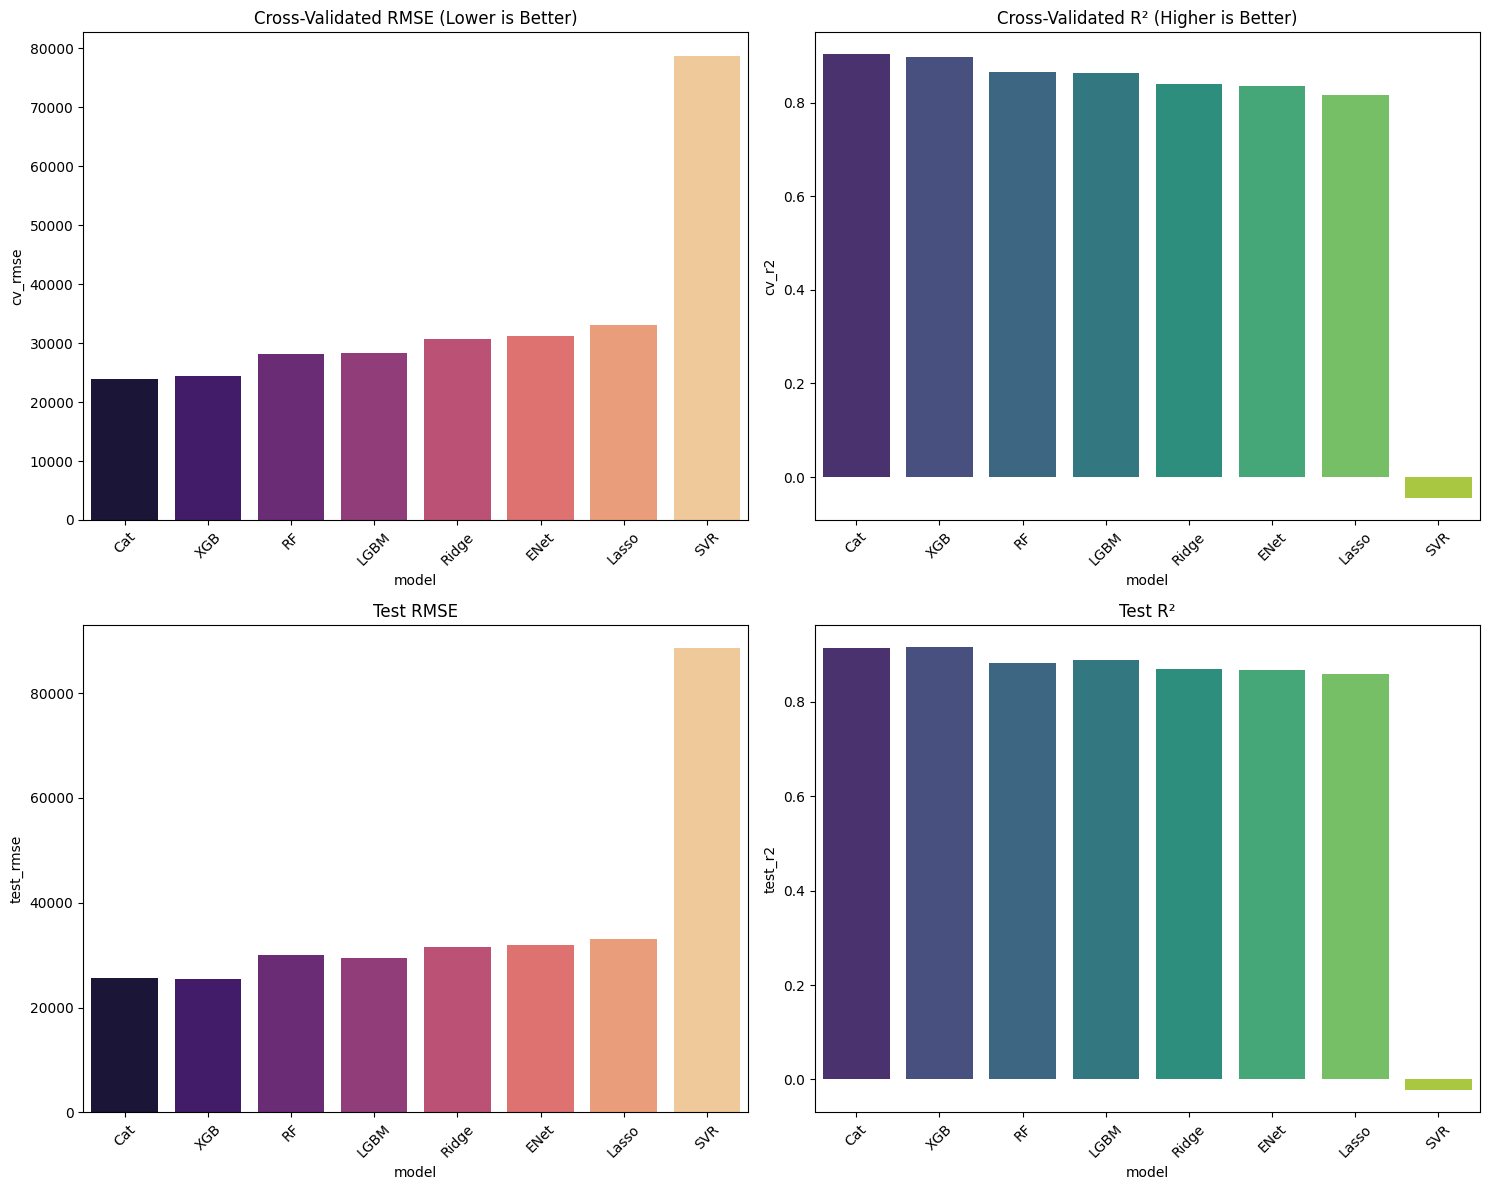


🏆 Best model: Cat
   CV RMSE: 23987.4425
   Test RMSE: 25726.6637


In [ ]:
if 'feature_pipe' in locals():
    models = base_models_dict()
    baseline_df, preds_test, top5 = run_baseline_with_cache(models, X_train, y_train, X_test, y_test, feature_pipe)

    # Mẹo: Tự động xác định tên cột thực tế có trong dataframe
    c_rmse = "cv_rmse_mean" if "cv_rmse_mean" in baseline_df.columns else "cv_rmse"
    c_r2 = "cv_r2_mean" if "cv_r2_mean" in baseline_df.columns else "cv_r2"

    with mlflow.start_run(run_name="Baseline_Visualization", nested=True):
        fig, axes = plt.subplots(2, 2, figsize=(15, 12)) # Tăng chiều cao một chút để không bị đè chữ

        # 1. CV RMSE
        sns.barplot(x="model", y=c_rmse, data=baseline_df, ax=axes[0,0], palette="magma")
        axes[0,0].set_title("Cross-Validated RMSE (Lower is Better)")
        axes[0,0].tick_params(axis='x', rotation=45)

        # 2. CV R2
        sns.barplot(x="model", y=c_r2, data=baseline_df, ax=axes[0,1], palette="viridis")
        axes[0,1].set_title("Cross-Validated R² (Higher is Better)")
        axes[0,1].tick_params(axis='x', rotation=45)

        # 3. Test RMSE
        sns.barplot(x="model", y="test_rmse", data=baseline_df, ax=axes[1,0], palette="magma")
        axes[1,0].set_title("Test RMSE")
        axes[1,0].tick_params(axis='x', rotation=45)

        # 4. Test R2
        sns.barplot(x="model", y="test_r2", data=baseline_df, ax=axes[1,1], palette="viridis")
        axes[1,1].set_title("Test R²")
        axes[1,1].tick_params(axis='x', rotation=45)

        plt.tight_layout()

        # Đảm bảo thư mục LOGS_DIR tồn tại
        os.makedirs(LOGS_DIR, exist_ok=True)

        plot_path = f"{LOGS_DIR}/baseline_model_comparison.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        mlflow.log_artifact(plot_path, "plots")
        plt.show()

        print(f"\n🏆 Best model: {baseline_df.iloc[0]['model']}")
        print(f"   CV RMSE: {baseline_df.iloc[0][c_rmse]:.4f}")
        print(f"   Test RMSE: {baseline_df.iloc[0]['test_rmse']:.4f}")
else:
    print("Please run the data preparation cell first!")

In [ ]:
# Chạy cái này để xóa sạch "ký ức" cũ
!rm -rf training_cache

## Hyperparameter tuning with Optuna

In [ ]:
def make_objective_with_mlflow(name, X_train, y_train, feature_pipe):
    """
    Tạo hàm objective cho Optuna tích hợp MLflow.
    Phù hợp với cấu trúc Pipeline và các biến hiện có trong Notebook.
    """
    def objective(trial):
        # Tạo một Nested Run cho mỗi trial để nhóm chúng lại dưới một Run cha
        with mlflow.start_run(run_name=f"Trial_{name}_{trial.number}", nested=True):

            # 1. Định nghĩa không gian tham số (Search Space)
            if name == "RF":
                params = {
                    "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=200),
                    "max_depth": trial.suggest_int("max_depth", 3, 20),
                    "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
                    "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
                    "random_state": RANDOM_STATE,
                    "n_jobs": -1 # RF chạy đa nhân tốt
                }
                model = RandomForestRegressor(**params)

            elif name == "Cat":
                params = {
                    "n_estimators": trial.suggest_int("n_estimators", 400, 2000, step=500), # Changed from 'iterations'
                    "depth": trial.suggest_int("depth", 4, 10),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                    "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
                    "random_state": RANDOM_STATE, "verbose": False, "loss_function": 'RMSE'
                }
                model = CatBoostRegressor(**params)

            elif name == "XGB":
                params = {
                    "n_estimators": trial.suggest_int("n_estimators", 400, 2000, step=500),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                    "max_depth": trial.suggest_int("max_depth", 3, 7),
                    "subsample": trial.suggest_float("subsample", 0.6, 0.9),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
                    "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
                    "tree_method": "hist",
                    "random_state": RANDOM_STATE,
                    "n_jobs": 1 # Để cross_validate kiểm soát n_jobs
                }
                model = xgb.XGBRegressor(**params)

            elif name == "LGBM":
                params = {
                    "n_estimators": trial.suggest_int("n_estimators", 400, 2000, step=500),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                    "num_leaves": trial.suggest_int("num_leaves", 20, 150),
                    "max_depth": trial.suggest_int("max_depth", 3, 12),
                    "subsample": trial.suggest_float("subsample", 0.6, 0.9),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
                    "random_state": RANDOM_STATE,
                    "n_jobs": 1,
                    "verbosity": -1
                }
                model = LGBMRegressor(**params)

            elif name in ["Ridge", "Lasso", "ENet"]:
                params = {"alpha": trial.suggest_float("alpha", 1e-3, 100.0, log=True), "random_state": RANDOM_STATE}
                if name == "Ridge": model = Ridge(**params)
                elif name == "Lasso": model = Lasso(**params)
                else:
                    params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.1, 0.9)
                    model = ElasticNet(**params)

            # Thêm các mô hình khác (ElasticNet, Lasso, CatBoost) tương tự...
            else:
                raise ValueError(f"Mô hình {name} chưa được cấu hình tuning.")

            # 2. Xây dựng Pipeline (Clone feature_pipe để đảm bảo tính độc lập)
            pipe = Pipeline([
                ("features", clone(feature_pipe)),
                ("model", model)
            ])

            # 3. Đánh giá bằng Cross-Validation
            cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

            # Sử dụng n_jobs=2 thay vì -1 trên Colab để tránh crash bộ nhớ
            scores = cross_validate(
                pipe, X_train, y_train,
                cv=cv,
                scoring=get_scorers(),
                n_jobs=2
            )

            # 4. Tính toán kết quả trung bình
            # Lưu ý: neg_rmse trong get_scorers trả về số âm, cần đảo dấu
            cv_rmse = -scores["test_neg_rmse"].mean()
            cv_r2 = scores["test_r2"].mean()

            # 5. Log lên MLflow
            mlflow.log_params(trial.params)
            mlflow.log_metrics({
                "cv_rmse": cv_rmse,
                "cv_r2": cv_r2
            })

            return cv_rmse # Optuna sẽ tối thiểu hóa giá trị này

    return objective

In [ ]:
def tune_single_model(name, X_train, y_train, feature_pipe, n_trials=20):
    """Tinh chỉnh 1 mô hình bằng Optuna và MLflow"""
    if not HAS_OPTUNA: return None, None

    print(f"🎯 Tuning {name} ({n_trials} trials)...")

    with mlflow.start_run(run_name=f"Tuning_{name}", nested=True):
        # 1. Chạy Optuna Optimization
        study = optuna.create_study(direction="minimize")
        objective = make_objective_with_mlflow(name, X_train, y_train, feature_pipe)
        study.optimize(objective, n_trials=n_trials, n_jobs=1) # n_jobs=1 để tránh crash Colab

        # 2. Lấy mô hình gốc từ dictionary và cập nhật tham số tốt nhất
        base_models = base_models_dict()
        best_model = base_models[name]

        # Cập nhật tham số (Xóa n_jobs, random_state ra khỏi best_params nếu có để tránh trùng)
        clean_params = {k: v for k, v in study.best_params.items() if k not in ['n_jobs', 'random_state']}
        best_model.set_params(**clean_params)

        # 3. Log kết quả
        mlflow.log_params(study.best_params)
        mlflow.log_metric("best_cv_rmse", study.best_value)

        return {"estimator": best_model, "best_cv_rmse": study.best_value, "best_params": study.best_params}, study.trials_dataframe()

def run_hyperparameter_tuning(top_names, X_train, y_train, feature_pipe, n_trials=15):
    """Điều phối Tuning cho danh sách Top mô hình"""
    # 1. Kiểm tra Cache (Kiểm tra coi có .pkl ko để chạy nhanh hơn đó :3)
    cached, _ = training_cache.load_results('tuning_results_v2')
    if cached:
        print("📂 Loading tuning results from cache..."); return cached['tuned'], cached['histories']

    tuned, histories = {}, {}
    print(f"🚀 Bắt đầu Tuning cho: {top_names}")

    with mlflow.start_run(run_name="Tuning_Summary", nested=True):
        # Chạy tuần tự để ổn định trên Colab, hoặc dùng Parallel nếu máy mạnh
        for name in top_names:
            result, history = tune_single_model(name, X_train, y_train, feature_pipe, n_trials)
            if result:
                tuned[name], histories[name] = result, history

        # 2. Lưu Cache
        training_cache.save_results({'tuned': tuned, 'histories': histories}, 'tuning_results')

    return tuned, histories

In [ ]:
print("=== 🛠️ HYPERPARAMETER TUNING CHECKPOINT ===")

# 1. Kiểm tra biến đầu vào
if 'top5' in locals() and 'feature_pipe' in locals():
    print(f"✅ Top 5 models sẵn sàng: {top5}")
    print(f"✅ Feature Pipeline sẵn sàng.")

    # 2. Kiểm tra xem hàm Tuning đã được định nghĩa chưa
    # Lưu ý: Tôi dùng tên hàm đã rút gọn ở bước trước
    tuning_func = 'run_hyperparameter_tuning'

    if tuning_func not in globals():
        print(f"❌ Lỗi: Hàm '{tuning_func}' chưa được định nghĩa!")
        print("👉 Giải pháp: Hãy chạy ô (cell) chứa định nghĩa hàm 'run_hyperparameter_tuning' trước.")
        tuned = {}
        histories = {}
    else:
        print("🚀 Bắt đầu quá trình Tuning (Optuna + MLflow)...")
        try:
            # Chạy Tuning (Bạn có thể chỉnh n_trials lên 30-50 nếu có thời gian)
            tuned, histories = run_hyperparameter_tuning(
                top5, X_train, y_train, feature_pipe, n_trials=15
            )

            if tuned:
                print(f"✅ Hoàn tất! Đã tối ưu hóa {len(tuned)} mô hình.")
                print(f"📦 Các mô hình đã tune: {list(tuned.keys())}")
            else:
                print("⚠️ Cảnh báo: Không có mô hình nào được tune thành công.")

        except Exception as e:
            print(f"❌ Lỗi phát sinh khi Tuning: {e}")
            import traceback
            traceback.print_exc()
            tuned = {}
            histories = {}
else:
    print("❌ Lỗi: Thiếu dữ liệu 'top5' hoặc 'feature_pipe'!")
    print("👉 Giải pháp: Bạn cần chạy phần 'Baseline Evaluation' ở phía trên để tìm ra Top 5 mô hình trước.")
    tuned = {}
    histories = {}

[I 2026-03-30 07:19:24,289] A new study created in memory with name: no-name-ead657cd-aecd-4527-9618-4280ab0a3fd2


=== 🛠️ HYPERPARAMETER TUNING CHECKPOINT ===
✅ Top 5 models sẵn sàng: ['Cat', 'XGB', 'RF', 'LGBM', 'Ridge']
✅ Feature Pipeline sẵn sàng.
🚀 Bắt đầu quá trình Tuning (Optuna + MLflow)...
🚀 Bắt đầu Tuning cho: ['Cat', 'XGB', 'RF', 'LGBM', 'Ridge']
🎯 Tuning Cat (15 trials)...


[I 2026-03-30 07:27:34,224] Trial 0 finished with value: 26774.57402315511 and parameters: {'n_estimators': 900, 'depth': 10, 'learning_rate': 0.011625311045837, 'l2_leaf_reg': 3.1347793002430286}. Best is trial 0 with value: 26774.57402315511.
[I 2026-03-30 07:28:44,236] Trial 1 finished with value: 23705.368394770972 and parameters: {'n_estimators': 1900, 'depth': 5, 'learning_rate': 0.010615556192959452, 'l2_leaf_reg': 1.7810244533836974}. Best is trial 1 with value: 23705.368394770972.
[I 2026-03-30 07:28:56,995] Trial 2 finished with value: 24430.41846249147 and parameters: {'n_estimators': 400, 'depth': 4, 'learning_rate': 0.07842463360178949, 'l2_leaf_reg': 1.9547234801137452}. Best is trial 1 with value: 23705.368394770972.
[I 2026-03-30 07:32:42,003] Trial 3 finished with value: 24711.865131597642 and parameters: {'n_estimators': 1400, 'depth': 8, 'learning_rate': 0.04051620592984008, 'l2_leaf_reg': 7.74284778209195}. Best is trial 1 with value: 23705.368394770972.
[I 2026-03-

🎯 Tuning XGB (15 trials)...


[I 2026-03-30 08:08:12,026] Trial 0 finished with value: 25398.548268958377 and parameters: {'n_estimators': 900, 'learning_rate': 0.014930186128217659, 'max_depth': 5, 'subsample': 0.6483464804095743, 'colsample_bytree': 0.896679250134208, 'reg_lambda': 9.60701767341229}. Best is trial 0 with value: 25398.548268958377.
[I 2026-03-30 08:08:36,034] Trial 1 finished with value: 25001.472064355406 and parameters: {'n_estimators': 900, 'learning_rate': 0.02810006598306772, 'max_depth': 6, 'subsample': 0.8477997682188518, 'colsample_bytree': 0.6315585392557277, 'reg_lambda': 0.3323907383490353}. Best is trial 1 with value: 25001.472064355406.
[I 2026-03-30 08:09:11,613] Trial 2 finished with value: 24629.818991310538 and parameters: {'n_estimators': 900, 'learning_rate': 0.052246047064808995, 'max_depth': 7, 'subsample': 0.6066555568229686, 'colsample_bytree': 0.7563441956287837, 'reg_lambda': 0.020686481100899125}. Best is trial 2 with value: 24629.818991310538.
[I 2026-03-30 08:09:15,540]

...

🎯 Tuning LGBM (15 trials)...


[I 2026-03-30 08:22:31,258] Trial 0 finished with value: 27958.172247118317 and parameters: {'n_estimators': 900, 'learning_rate': 0.04148533510278462, 'num_leaves': 132, 'max_depth': 12, 'subsample': 0.6742864827751857, 'colsample_bytree': 0.8098452953662181}. Best is trial 0 with value: 27958.172247118317.
[I 2026-03-30 08:22:48,319] Trial 1 finished with value: 27974.74375273944 and parameters: {'n_estimators': 1900, 'learning_rate': 0.013030407039069292, 'num_leaves': 102, 'max_depth': 11, 'subsample': 0.8684138114072835, 'colsample_bytree': 0.8092110994177997}. Best is trial 0 with value: 27958.172247118317.
[I 2026-03-30 08:22:57,054] Trial 2 finished with value: 27501.638811210672 and parameters: {'n_estimators': 900, 'learning_rate': 0.041867034138331524, 'num_leaves': 112, 'max_depth': 9, 'subsample': 0.8306645623580817, 'colsample_bytree': 0.693188121617223}. Best is trial 2 with value: 27501.638811210672.
[I 2026-03-30 08:23:00,203] Trial 3 finished with value: 26809.6633135

🎯 Tuning Ridge (15 trials)...


[I 2026-03-30 08:24:15,869] Trial 0 finished with value: 30602.55800883445 and parameters: {'alpha': 65.76612126955173}. Best is trial 0 with value: 30602.55800883445.
[I 2026-03-30 08:24:18,480] Trial 1 finished with value: 32882.065926054725 and parameters: {'alpha': 0.04571346788979014}. Best is trial 0 with value: 30602.55800883445.
[I 2026-03-30 08:24:19,895] Trial 2 finished with value: 30459.76246908407 and parameters: {'alpha': 38.382497415471185}. Best is trial 2 with value: 30459.76246908407.
[I 2026-03-30 08:24:21,366] Trial 3 finished with value: 31307.422669295534 and parameters: {'alpha': 3.649452302717548}. Best is trial 2 with value: 30459.76246908407.
[I 2026-03-30 08:24:22,877] Trial 4 finished with value: 32971.28556911347 and parameters: {'alpha': 0.007338928728931193}. Best is trial 2 with value: 30459.76246908407.
[I 2026-03-30 08:24:24,444] Trial 5 finished with value: 31614.576383213094 and parameters: {'alpha': 2.226499902436809}. Best is trial 2 with value: 30

💾 Cached training results: tuning_results
✅ Hoàn tất! Đã tối ưu hóa 5 mô hình.
📦 Các mô hình đã tune: ['Cat', 'XGB', 'RF', 'LGBM', 'Ridge']


=== FINAL RESULTS AND COMPARISON (SINGLE MODELS) ===
💾 Đã lưu mô hình hoàn chỉnh tại: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/logs/final_house_price_model.pkl


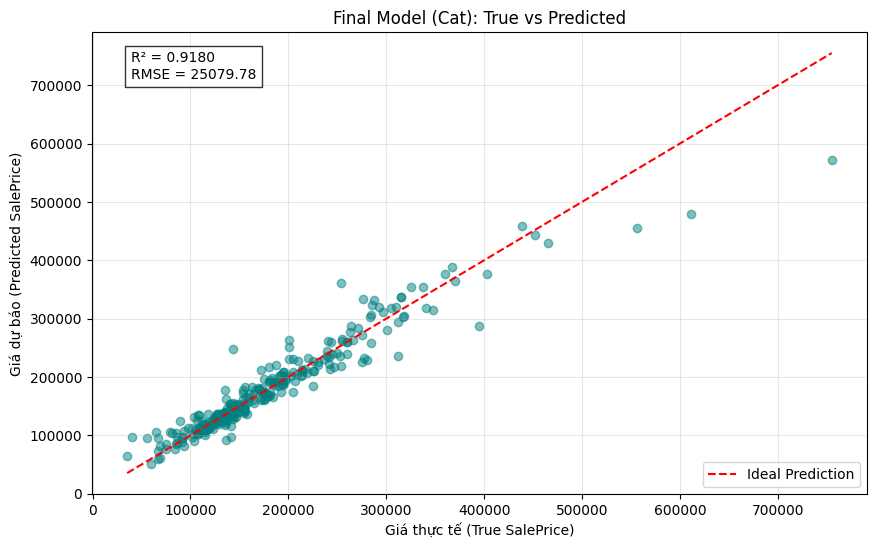


📈 Hiệu quả sau khi Tuning Cat:
   Test RMSE: 25079.78


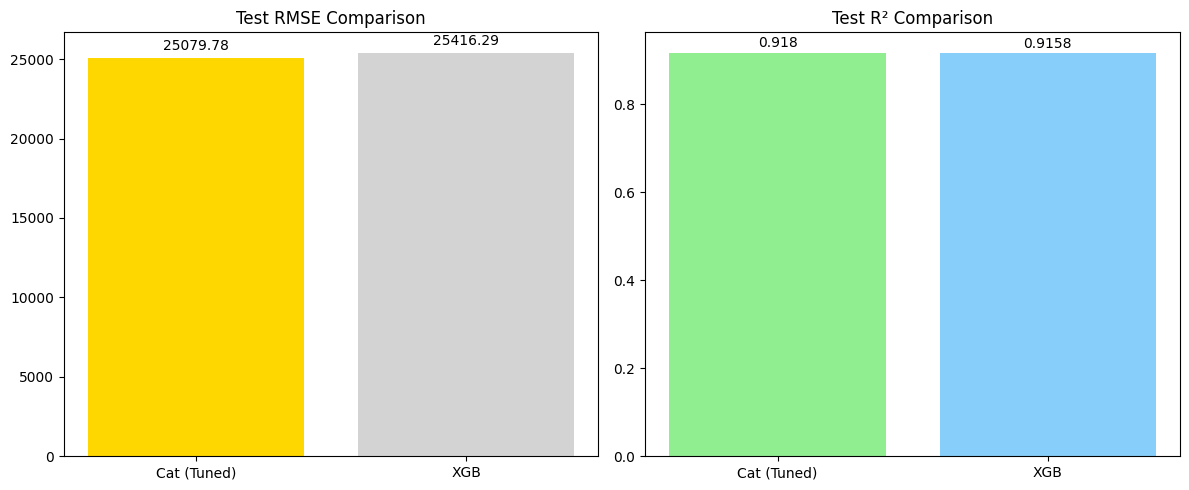


=== FINAL SUMMARY RANKING ===
         model   test_rmse  test_r2
8  Cat (Tuned)  25079.7794   0.9180
5          XGB  25416.2936   0.9158
6          Cat  25726.6637   0.9137
7         LGBM  29378.0810   0.8875
0           RF  30030.9710   0.8824
2        Ridge  31567.8652   0.8701
1         ENet  31857.7502   0.8677
3        Lasso  33013.1945   0.8579
4          SVR  88575.6697  -0.0229


In [ ]:
import dill

if 'tuned' in locals() and tuned:
    with mlflow.start_run(run_name="Final_Model_Analysis", nested=True):
        print("=== FINAL RESULTS AND COMPARISON (SINGLE MODELS) ===")

        # 1. Tìm mô hình tốt nhất trong danh sách các mô hình đã được Tuning
        best_tuned_name = min(tuned.keys(), key=lambda k: tuned[k]['best_cv_rmse'])
        best_tuned_info = tuned[best_tuned_name]
        best_tuned_estimator = best_tuned_info['estimator']

        # 2. Xây dựng và đánh giá Pipeline cuối cùng trên tập Test
        final_pipe = Pipeline([
            ("features", clone(feature_pipe)),
            ("model", best_tuned_estimator)
        ])

        final_pipe.fit(X_train, y_train)
        y_pred_final = final_pipe.predict(X_test)
        final_metrics = get_metrics(y_test, y_pred_final)

        # --- LƯU MÔ HÌNH THÀNH FILE .PKL DÙNG DILL ---
        model_save_path = f"{LOGS_DIR}/final_house_price_model.pkl"
        try:
            with open(model_save_path, 'wb') as f:
                dill.dump(final_pipe, f)
            print(f"💾 Đã lưu mô hình hoàn chỉnh tại: {model_save_path}")
            mlflow.log_artifact(model_save_path)
        except Exception as e:
            print(f"❌ Lỗi khi lưu model: {e}")

        # Log kết quả cuối cùng vào MLflow
        mlflow.log_param("final_model_name", best_tuned_name)
        mlflow.log_params(best_tuned_info['best_params'])
        mlflow.log_metric("final_test_rmse", final_metrics["rmse"])
        mlflow.log_metric("final_test_r2", final_metrics["r2"])

        # Create summary_df here so it's available for top model selection
        summary_df = baseline_df[['model', 'test_rmse', 'test_r2']].copy()
        summary_df.loc[len(summary_df)] = [f"{best_tuned_name} (Tuned)", final_metrics["rmse"], final_metrics["r2"]]
        summary_df = summary_df.sort_values("test_rmse")

        # 3. Vẽ đồ thị True vs Predicted cho mô hình tốt nhất
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred_final, alpha=0.5, color='teal')
        line = np.linspace(y_test.min(), y_test.max(), 100)
        plt.plot(line, line, color='red', linestyle='--', label='Ideal Prediction')

        plt.xlabel("Giá thực tế (True SalePrice)")
        plt.ylabel("Giá dự báo (Predicted SalePrice)")
        plt.title(f"Final Model ({best_tuned_name}): True vs Predicted")
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.text(0.05, 0.9, f'R² = {final_metrics["r2"]:.4f}\nRMSE = {final_metrics["rmse"]:.2f}',
                 transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

        plot_path = f"{LOGS_DIR}/final_prediction_scatter.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        mlflow.log_artifact(plot_path, "final_results")
        plt.show()

        # 4. So sánh Top 1 và Top 2
        summary_df_sorted = summary_df.sort_values("test_rmse", ascending=True)
        top1_model = summary_df_sorted.iloc[0]
        top2_model = summary_df_sorted.iloc[1]

        print(f"\n📈 Hiệu quả sau khi Tuning {best_tuned_name}:")
        print(f"   Test RMSE: {final_metrics['rmse']:.2f}")

        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        labels = [top1_model['model'], top2_model['model']]
        rmses = [top1_model["test_rmse"], top2_model["test_rmse"]]
        r2s = [top1_model["test_r2"], top2_model["test_r2"]]

        bars_rmse = ax[0].bar(labels, rmses, color=['gold', 'lightgrey'])
        ax[0].set_title("Test RMSE Comparison")
        for bar in bars_rmse:
            yval = bar.get_height()
            ax[0].text(bar.get_x() + bar.get_width()/2, yval + 300, round(yval, 2), ha='center', va='bottom')

        bars_r2 = ax[1].bar(labels, r2s, color=['lightgreen', 'lightskyblue'])
        ax[1].set_title("Test R² Comparison")
        for bar in bars_r2:
            yval = bar.get_height()
            ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        # 5. Tổng kết
        print("\n=== FINAL SUMMARY RANKING ===")
        print(summary_df.round(4))
        summary_df.to_csv(f"{LOGS_DIR}/final_ranking.csv", index=False)
        mlflow.log_artifact(f"{LOGS_DIR}/final_ranking.csv")
else:
    print("⚠️ Vui lòng chạy bước Hyperparameter Tuning (Optuna) trước!")

In [ ]:
# Cài đặt dill để hỗ trợ serialize các custom classes trong notebook
!pip install dill -q

In [ ]:
import yaml
from datetime import datetime

def extract_model_config(best_model_name, tuned_models, baseline_df, feature_pipe):
    """Extract configuration for the best model using variables available in the notebook"""

    config = {
        'model_info': {
            'name': best_model_name,
            'type': 'Single' if best_model_name not in ['Stack', 'Ensemble'] else 'Ensemble',
            'timestamp': datetime.now().isoformat(),
            'model_version': '1.0'
        },
        'performance': {},
        'hyperparameters': {},
        'feature_engineering': {
            'domain_features': [
                "TotalSF", "TotalBath", "HouseAge", "RemodAge", "GarageAge",
                "IsRemodeled", "Has2ndFlr", "TotalPorchSF", "BathPerBedroom",
                "RoomsPerArea", "LotAreaRatio", "MoSold_sin", "MoSold_cos",
                "Neighborhood_BldgType", "Ln_TotalSF", "IQ_OQ_GrLiv", "IQ_OQ_TotalSF", "LotArea_clip"
            ],
            'target_encoder_features': ["Neighborhood","MSZoning","Exterior1st","Exterior2nd","SaleCondition","BldgType","Neighborhood_BldgType"],
            'target_encoder_alpha': 30.0,
            'rare_pooler_min_count': 15,
            'quantile_transformer_n_quantiles': 200,
            'quantile_transformer_subsample': 200000,
            'imputation_strategy_categorical': 'most_frequent',
            'imputation_strategy_numerical': 'median'
        },
        'preprocessing': {
            'ordinal_features': list(ORDINAL_MAP_CANONICAL.keys()),
            'missingness_indicator_auto': True,
            'one_hot_encoder_handle_unknown': 'ignore'
        }
    }

    # Extract performance metrics from the existing baseline_df
    if best_model_name in baseline_df['model'].values:
        best_row = baseline_df[baseline_df['model'] == best_model_name].iloc[0]
        # Map existing columns to the config structure
        config['performance'] = {
            'cv_rmse': float(best_row['cv_rmse']) if 'cv_rmse' in best_row else None,
            'cv_r2': float(best_row['cv_r2']) if 'cv_r2' in best_row else None,
            'test_rmse': float(best_row['test_rmse']),
            'test_r2': float(best_row['test_r2'])
        }

    # Extract hyperparameters from the 'tuned' dictionary
    if best_model_name in tuned_models:
        config['hyperparameters'] = tuned_models[best_model_name]['best_params']
    else:
        base_models = base_models_dict()
        if best_model_name in base_models:
            model = base_models[best_model_name]
            if hasattr(model, 'get_params'):
                config['hyperparameters'] = model.get_params()

    return config

def export_config_to_yaml(config, output_path):
    """Export model configuration to YAML file with type conversion"""
    def convert_types(obj):
        if isinstance(obj, dict):
            return {k: convert_types(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_types(item) for item in obj]
        elif isinstance(obj, (np.integer, np.floating)):
            return obj.item()
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, (np.bool_, bool)):
            return bool(obj)
        else:
            return obj

    config_clean = convert_types(config)
    with open(output_path, 'w') as f:
        yaml.dump(config_clean, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
    print(f"✅ Configuration exported to: {output_path}")

print("Configuration extraction and YAML export functions defined!")

Configuration extraction and YAML export functions defined!


In [ ]:
if 'best_tuned_name' in locals() and 'tuned' in locals():
    # Extract and save config for the best performing model
    best_config = extract_model_config(best_tuned_name, tuned, baseline_df, feature_pipe)
    yaml_path = f"{LOGS_DIR}/best_model_config.yaml"
    export_config_to_yaml(best_config, yaml_path)

    # Log as artifact to MLflow
    with mlflow.start_run(run_name="Config_Export", nested=True):
        mlflow.log_artifact(yaml_path)
else:
    print("⚠️ Final analysis has not been run yet. Please run the Final Model Analysis cell first.")

✅ Configuration exported to: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/logs/best_model_config.yaml


In [ ]:
import json as json_lib

if 'baseline_df' in locals() and baseline_df is not None:
    with mlflow.start_run(run_name="Best_Model_Configuration_Export", nested=True):
        print("=== EXTRACTING BEST MODEL CONFIGURATION ===")

        # Determine best performing model
        # We check both baseline and tuned results stored in baseline_df/summary_df
        current_results = summary_df if 'summary_df' in locals() else baseline_df
        best_row = current_results.sort_values("test_rmse").iloc[0]
        best_model_name = best_row["model"].replace(" (Tuned)", "")

        print(f"🏆 Best model identified: {best_row['model']}")
        print(f"   Test RMSE: {best_row['test_rmse']:.4f}")
        print(f"   Test R²: {best_row['test_r2']:.4f}")

        # Extract configuration using previously defined helper
        tuned_dict = tuned if 'tuned' in locals() else {}
        config = extract_model_config(best_model_name, tuned_dict, baseline_df, feature_pipe)

        # Display configuration summary
        print("\n=== CONFIGURATION SUMMARY ===")
        print(f"Model: {config['model_info']['name']}")
        print(f"Timestamp: {config['model_info']['timestamp']}")

        if config['performance']:
            print("\nPerformance Metrics:")
            print(f"  Test RMSE: {config['performance'].get('test_rmse'):.4f}")
            print(f"  Test R²: {config['performance'].get('test_r2'):.4f}")

        if config['hyperparameters']:
            print(f"\nHyperparameters ({len(config['hyperparameters'])} parameters):")
            for key, value in list(config['hyperparameters'].items())[:5]:
                print(f"  {key}: {value}")

        # Export Paths
        yaml_path = f"{LOGS_DIR}/best_model_config.yaml"
        json_path = f"{LOGS_DIR}/best_model_config.json"

        # Export to YAML
        export_config_to_yaml(config, yaml_path)

        # Export to JSON (Native Python types already handled by extract_model_config logic)
        with open(json_path, 'w') as f:
            json_lib.dump(config, f, indent=2, default=str)

        # Log to MLflow
        mlflow.log_params({
            "exported_model": config['model_info']['name'],
            "model_type": config['model_info']['type']
        })
        if config['performance']:
            mlflow.log_metrics({
                "final_rmse": config['performance'].get('test_rmse'),
                "final_r2": config['performance'].get('test_r2')
            })

        mlflow.log_artifact(yaml_path, "config")
        mlflow.log_artifact(json_path, "config")

        print(f"\n✅ Exported YAML & JSON to: {LOGS_DIR}")
else:
    print("❌ Please run the evaluation steps first!")

=== EXTRACTING BEST MODEL CONFIGURATION ===
🏆 Best model identified: Cat (Tuned)
   Test RMSE: 25079.7794
   Test R²: 0.9180

=== CONFIGURATION SUMMARY ===
Model: Cat
Timestamp: 2026-03-30T10:22:30.380068

Performance Metrics:
  Test RMSE: 25726.6637
  Test R²: 0.9137

Hyperparameters (4 parameters):
  n_estimators: 1400
  depth: 4
  learning_rate: 0.043324434907107134
  l2_leaf_reg: 1.261603284317759
✅ Configuration exported to: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/logs/best_model_config.yaml

✅ Exported YAML & JSON to: /content/drive/MyDrive/Colab_Notebooks/Project-5.1/logs
